# Notebook 07: Feature Engineering Checkpoint

This notebook records the feature-engineering checkpoint in the updated XGBoost sequence. The saved output names still follow the original run label so that the notebook remains consistent with earlier artifacts.

06_xgboost_test_3: Feature engineering 

1. Load data... 
Train shape: (700000, 26) 

2. Prepare data... 

Create engineered features: 
 ✓ cardio_risk_score created 
 ✓ age_family_history created 
 ✓ age_bmi created 
 ✓ Cholesterol metrics created 
 ✓ metabolic_score created 
 ✓ bp_stage created 
 ✓ bmi_category created 

Created a total of 8 new features 

3. Encode categorical features... 
Total encoded feature count: 50 
Train set: (560000, 50), Validation set: (140000, 50) 

scale_pos_weight: 0.604

Best results from Experiment 05: 
- AUC: 0.7264
- Recall class 0: 0.692 
- Recall class 1: 0.635 
- Best threshold: 0.45 

4. Train XGBoost (depth=6, 300 trees) + engineered features... 
[0]	validation_0-auc:0.68977
[50]	validation_0-auc:0.71173
[100]	validation_0-auc:0.71939
[150]	validation_0-auc:0.72224
[200]	validation_0-auc:0.72379
[250]	validation_0-auc:0.72457
[299]	validation_0-auc:0.72511

5. Model evaluation... 

06_xgboost_test_3 results: 
- AUC: 0.7251
- Recall class 0: 0.69

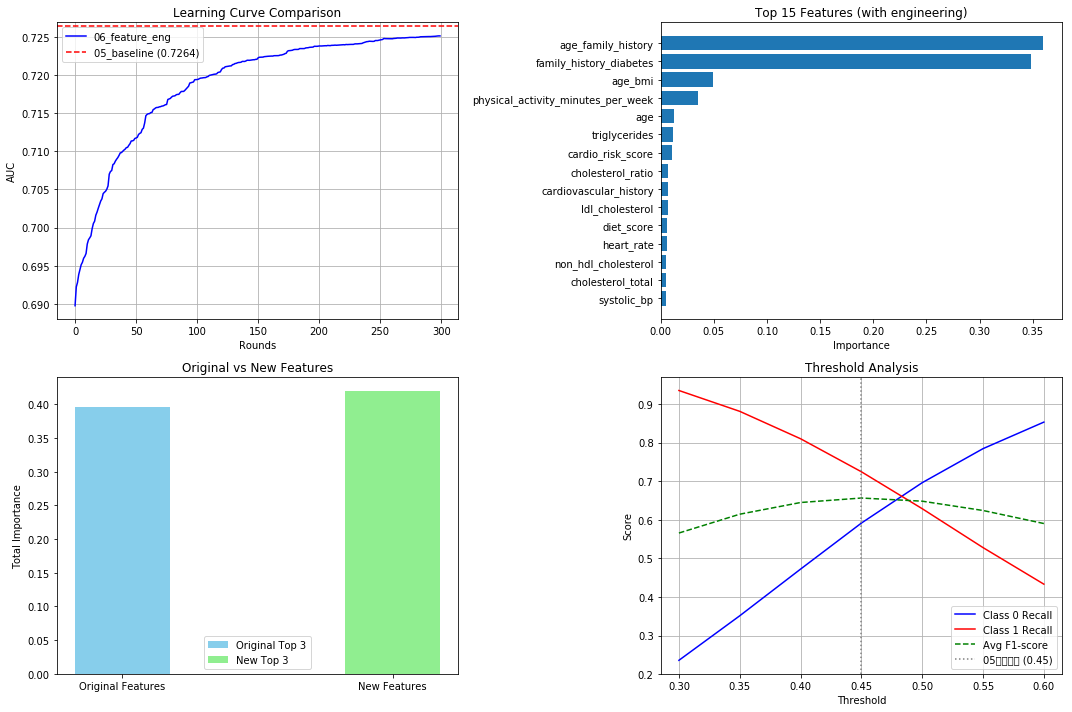


7. Threshold optimization analysis... 

Performance under different thresholds: 
----------------------------------------------------------------------
Threshold Recall class 0 Recall class 1 gap F1_avg 
----------------------------------------------------------------------
0.30     0.236      0.935      0.699    0.566   
0.35     0.351      0.881      0.530    0.615   
0.40     0.472      0.810      0.338    0.645   
0.45     0.592      0.725      0.133    0.657   
0.50     0.696      0.629      -0.067   0.648   
0.55     0.785      0.528      -0.257   0.624   
0.60     0.853      0.433      -0.420   0.590   
----------------------------------------------------------------------
Best threshold: 0.45 (Mean F1=0.657) 

8. Save model and submission file... 
Model saved to ../models/06_xgboost_test_3.pkl 

Create engineered features: 
 ✓ cardio_risk_score created 
 ✓ age_family_history created 
 ✓ age_bmi created 
 ✓ Cholesterol metrics created 
 ✓ metabolic_score created 
 ✓ bp_stage cr

In [ ]:
# 06_xgboost_test_3.ipynb
# Experiment:Feature engineering based on medical knowledge

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, recall_score, f1_score
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("06_xgboost_test_3: Feature engineering") 
print("="*60)

# 1. Load data
print("\n1. Load data...") 
train = pd.read_csv('../data/train.csv')
print(f"Train shape: {train.shape}") 

# 2. Feature engineering function
def create_medical_features(df):
    """Create medical-related combined features""" 
    df_new = df.copy()
    
    print("\nCreate engineered features:") 
    
    # 2.1 Cardiovascular risk combination (based on top features)
    df_new['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3 +
        df['hypertension_history'] * 2 +
        df['cardiovascular_history'] * 2
    )
    print(" ✓ cardio_risk_score created") 
    
    # 2.2 Age and family history interaction (two strongest features)
    df_new['age_family_history'] = df['age'] * df['family_history_diabetes']
    print(" ✓ age_family_history created") 
    
    # 2.3 Age and BMI interaction
    df_new['age_bmi'] = df['age'] * df['bmi']
    print(" ✓ age_bmi created") 
    
    # 2.4 cholesterol ratio (clinically important)
    df_new['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df_new['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    print(" ✓ Cholesterol metrics created") 
    
    # 2.5 Metabolic syndrome score
    df_new['metabolic_score'] = (
        (df['bmi'] > 30).astype(int) +
        (df['triglycerides'] > 150).astype(int) +
        (df['hdl_cholesterol'] < 40).astype(int) +
        (df['systolic_bp'] > 130).astype(int) +
        (df['waist_to_hip_ratio'] > 0.9).astype(int)
    )
    print(" ✓ metabolic_score created") 
    
    # 2.6 Blood pressure stage
    df_new['bp_stage'] = pd.cut(
        df['systolic_bp'],
        bins=[0, 120, 130, 140, 200],
        labels=[0, 1, 2, 3]
    ).astype(float)
    print(" ✓ bp_stage created") 
    
    # 2.7 BMI category
    df_new['bmi_category'] = pd.cut(
        df['bmi'],
        bins=[0, 18.5, 25, 30, 100],
        labels=[0, 1, 2, 3]
    ).astype(float)
    print(" ✓ bmi_category created") 
    
    print(f"\nCreated a total of {len(df_new.columns) - len(df.columns)} new features") 
    return df_new

# 3. Prepare data(original features)
print("\n2. Prepare data...") 
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']

X_fe = create_medical_features(X)

# 4. Encode categorical features
print("\n3. Encode categorical features...") 
categorical_cols = ['gender', 'ethnicity', 'education_level', 
                   'income_level', 'smoking_status', 'employment_status']

X_encoded = pd.get_dummies(X_fe, columns=categorical_cols)
print(f"Total encoded feature count: {X_encoded.shape[1]}") 

# 5. Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}") 

# 6. Compute weights(using the best parameters from Experiment 05)
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")

# 7. Best results from Experiment 05(for comparison)
prev_exp = {
    'name': '05_xgboost_test_2',
    'auc': 0.7264,
    'recall_0': 0.692,
    'recall_1': 0.635,
    'threshold': 0.45
}

print(f"\nBest results from Experiment 05:") 
print(f"- AUC: {prev_exp['auc']}")
print(f"- Recall class 0: {prev_exp['recall_0']}") 
print(f"- Recall class 1: {prev_exp['recall_1']}") 
print(f"- Best threshold: {prev_exp['threshold']}") 

# 8. Train model(using the best parameters from Experiment 05, but with engineered features)
print("\n4. Train XGBoost (depth=6, 300 trees) + engineered features...") 

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    use_label_encoder=False
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# 9. Evaluation
print("\n5. Model evaluation...") 
y_pred_proba = xgb_model.predict_proba(X_val)[:, 1]
y_pred = xgb_model.predict(X_val)

current_auc = roc_auc_score(y_val, y_pred_proba)
recall_0 = recall_score(y_val, y_pred, pos_label=0)
recall_1 = recall_score(y_val, y_pred, pos_label=1)
recall_gap = recall_1 - recall_0

print(f"\n06_xgboost_test_3 results:") 
print(f"- AUC: {current_auc:.4f}")
print(f"- Recall class 0: {recall_0:.3f}") 
print(f"- Recall class 1: {recall_1:.3f}") 
print(f"- Recall gap: {recall_gap:.3f}") 

print(f"\nCompare with Experiment 05:") 
print(f"- AUC improvement: +{current_auc - prev_exp['auc']:.4f}") 
print(f"- Recall change: class 0 {prev_exp['recall_0']:.3f}->{recall_0:.3f}, class 1 {prev_exp['recall_1']:.3f}->{recall_1:.3f}") 

print("\nClassification report:") 
print(classification_report(y_val, y_pred))

# 10. Feature importance analysis
print("\n6. Feature importance analysis...") 

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:") 
print(importance.head(15).to_string(index=False))

print("\nRanking of engineered feature importance:") 
new_features = ['cardio_risk_score', 'age_family_history', 'age_bmi',
                'cholesterol_ratio', 'non_hdl_cholesterol',
                'metabolic_score', 'bp_stage', 'bmi_category']

new_feat_importance = importance[importance['feature'].isin(new_features)]
if len(new_feat_importance) > 0:
    print(new_feat_importance.to_string(index=False))
else:
    print("No engineered features entered the top 15") 

# 11. Visualization
plt.figure(figsize=(15, 10))

# Learning curve comparison
plt.subplot(2, 2, 1)
results = xgb_model.evals_result()
plt.plot(results['validation_0']['auc'], 'b-', label='06_feature_eng')
plt.axhline(y=prev_exp['auc'], color='r', linestyle='--', label=f'05_baseline ({prev_exp["auc"]})')
plt.xlabel('Rounds')
plt.ylabel('AUC')
plt.title('Learning Curve Comparison')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
top_features = importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Features (with engineering)')
plt.gca().invert_yaxis()

# Compare old and new feature importance
plt.subplot(2, 2, 3)
old_features = ['family_history_diabetes', 'age', 'physical_activity_minutes_per_week']
old_importance = [importance[importance['feature'] == f]['importance'].values[0] for f in old_features]

if len(new_feat_importance) >= 3:
    new_top3 = new_feat_importance.head(3)['feature'].tolist()
    new_importance = new_feat_importance.head(3)['importance'].tolist()
else:
    new_top3 = ['No new features']
    new_importance = [0]

x = np.arange(2)
width = 0.35
plt.bar(x[0], sum(old_importance), width, label='Original Top 3', color='skyblue')
plt.bar(x[1], sum(new_importance[:3]), width, label='New Top 3', color='lightgreen')
plt.xticks(x, ['Original Features', 'New Features'])
plt.ylabel('Total Importance')
plt.title('Original vs New Features')
plt.legend()

plt.subplot(2, 2, 4)
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
recall_0_list = []
recall_1_list = []
f1_avg_list = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(float)
    r0 = recall_score(y_val, y_pred_thresh, pos_label=0)
    r1 = recall_score(y_val, y_pred_thresh, pos_label=1)
    f1_0 = f1_score(y_val, y_pred_thresh, pos_label=0)
    f1_1 = f1_score(y_val, y_pred_thresh, pos_label=1)
    recall_0_list.append(r0)
    recall_1_list.append(r1)
    f1_avg_list.append((f1_0 + f1_1) / 2)

plt.plot(thresholds, recall_0_list, 'b-', label='Class 0 Recall')
plt.plot(thresholds, recall_1_list, 'r-', label='Class 1 Recall')
plt.plot(thresholds, f1_avg_list, 'g--', label='Avg F1-score')
plt.axvline(x=prev_exp['threshold'], color='gray', linestyle=':', label=f"05Best threshold ({prev_exp['threshold']})") 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Analysis')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('../logs/06_xgboost_test_3_plots.png', dpi=100, bbox_inches='tight')
plt.show()

# 12. Find the best threshold
print("\n7. Threshold optimization analysis...") 
best_f1_avg = 0
best_threshold = 0.5

print("\nPerformance under different thresholds:") 
print("-" * 70)
print(f"{'Threshold':<8} {'Recall class 0':<10} {'Recall class 1':<10} {'gap':<8} {'F1_avg':<8}") 
print("-" * 70)

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(float)
    r0 = recall_score(y_val, y_pred_thresh, pos_label=0)
    r1 = recall_score(y_val, y_pred_thresh, pos_label=1)
    f1_0 = f1_score(y_val, y_pred_thresh, pos_label=0)
    f1_1 = f1_score(y_val, y_pred_thresh, pos_label=1)
    f1_avg = (f1_0 + f1_1) / 2
    gap = r1 - r0
    print(f"{thresh:<8.2f} {r0:<10.3f} {r1:<10.3f} {gap:<8.3f} {f1_avg:<8.3f}")
    
    if f1_avg > best_f1_avg:
        best_f1_avg = f1_avg
        best_threshold = thresh

print("-" * 70)
print(f"Best threshold: {best_threshold} (Mean F1={best_f1_avg:.3f})") 

# 13. Save model and submission file
print("\n8. Save model and submission file...") 

model_path = '../models/06_xgboost_test_3.pkl'
joblib.dump(xgb_model, model_path)
print(f"Model saved to {model_path}") 

test = pd.read_csv('../data/test.csv')
X_test = test.drop(['id'], axis=1)
X_test_fe = create_medical_features(X_test)
X_test_encoded = pd.get_dummies(X_test_fe, columns=categorical_cols)

missing_cols = set(X_train.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train.columns]

test_pred = xgb_model.predict_proba(X_test_encoded)[:, 1]

submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': test_pred
})
submission_path = '../submissions/06_xgboost_test_3.csv'
submission.to_csv(submission_path, index=False)
print(f"Submission file saved to {submission_path}") 

# 14. Experiment summary
print("\n" + "="*60)
print("06_xgboost_test_3 summary report") 
print("="*60)

summary = f"""
[Experiment Information]
File Name: 06_xgboost_test_3
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
Experiment Type: Feature Engineering

[Parameters]
- n_estimators: 300 (from 05 best)
- learning_rate: 0.1
- max_depth: 6 (from 05 best)
- scale_pos_weight: {scale_pos_weight:.3f}

[New Features Created]
1. cardio_risk_score: Family history + hypertension + cardiovascular
2. age_family_history: Age × family history
3. age_bmi: Age × BMI
4. cholesterol_ratio, non_hdl_cholesterol
5. metabolic_score: Metabolic syndrome indicators
6. bp_stage: Blood pressure classification
7. bmi_category: BMI classification

[Results Comparison]
05_xgboost_test_2 (baseline):
- AUC: {prev_exp['auc']}
- Class 0 Recall: {prev_exp['recall_0']}
- Class 1 Recall: {prev_exp['recall_1']}
- Best Threshold: {prev_exp['threshold']}

06_xgboost_test_3 (with feature engineering):
- AUC: {current_auc:.4f}
- Class 0 Recall: {recall_0:.3f}
- Class 1 Recall: {recall_1:.3f}
- Best Threshold: {best_threshold}

[Improvement]
- AUC Change: {current_auc - prev_exp['auc']:+.4f}

[Key Findings]
1. Feature engineering effect: {'✓ Positive' if current_auc > prev_exp['auc'] else '✗ Negative'} 
2. {'新特征有帮助' if len(new_feat_importance) > 0 else '新特征未进入前15'} 

[Top New Features]
{new_feat_importance.head(3).to_string(index=False) if len(new_feat_importance) > 0 else 'None'}

[Next Steps]
{'- Try learning rate tuning (07_xgboost_test_4)' if current_auc > prev_exp['auc'] else '- Try different feature combinations'}
{'- Consider LightGBM (08_xgboost_test_5)' if current_auc < 0.728 else '- Try model ensemble'}
"""
print(summary)


# Experiment 7 Summary: Feature Engineering Test

## Role in the series
This notebook examines whether simple domain-motivated engineered features can complement the tuned boosting setup. The goal is to test whether added structure helps beyond parameter tuning alone.

## Interpretation
The results are best read as a methodological checkpoint rather than a guaranteed improvement. They help clarify which kinds of engineered signals appear useful and reinforce the later decision to keep original features while adding engineered ones as complements.

## Reproducibility note
The code cell and saved outputs retain their original run label for consistency with previously generated artifacts.